Incorporating correction for the selection effects with numpyro's model.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee

import jax
import numpyro
import jax.numpy as jnp
import numpyro.distributions as dist

from chainconsumer import ChainConsumer, Chain

import getdist
from getdist import plots, MCSamples

from jax.scipy.special import erf as jax_erf


def getdist_plot(results_chain, param_names, true_params, pred_params):
    # Create getdist object from chain
    getdist_mcsample = getdist.MCSamples(samples=results_chain.T, names=param_names)

    # Triangle plot
    g = getdist.plots.get_subplot_plotter()
    g.settings.legend_fontsize = 25
    g.settings.axes_fontsize = 15
    g.settings.axes_labelsize = 20
    g.triangle_plot(roots=getdist_mcsample, filled=True)

    ndim = results_chain.shape[0]

    for i in range(ndim):
        for j in range(ndim):
            if j <= i:
                ax = g.subplots[i, j]

                # Diagonal
                if i == j:
                    ax.axvline(true_params[i], color='r', ls='--')
                    ax.axvline(pred_params[i], color='g', ls='--')
                else:
                    # Off-diagonal
                    ax.axvline(true_params[j], color='r', ls='--')
                    ax.axhline(true_params[i], color='r', ls='--')

                    ax.axvline(pred_params[j], color='g', ls='--')
                    ax.axhline(pred_params[i], color='g', ls='--')

                ax.set_xlabel(ax.get_xlabel(), usetex=True, fontsize=25, family='sans-serif')
                ax.set_ylabel(ax.get_ylabel(), usetex=True, fontsize=25, family='sans-serif')
                ax.tick_params(axis='both', which='major', labelsize=15)


# Truncated 1D Gaussian with no errors

True parameters:  [5.0, 1.0, 3.5]
Predicted parameters:  [Array(5.1396623, dtype=float32), Array(0.88122535, dtype=float32), Array(3.5001721, dtype=float32)]


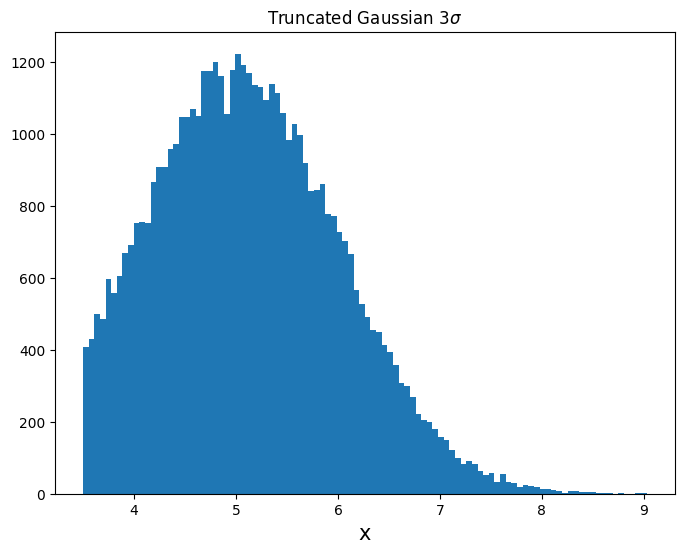

In [2]:
np.random.seed(42)

# Generate data
sigma_cut = 1.5
N_data = 50000
mean_x = 5.0
sigma_x = 1.0
x_min = mean_x - sigma_cut * sigma_x
true_params = [mean_x, sigma_x, x_min]

x_data = dist.TruncatedNormal(loc=mean_x, scale=sigma_x, low=x_min).sample(jax.random.PRNGKey(0), sample_shape=(N_data,))

# Predicted analytical values
mu_x_pred = np.mean(x_data)
sigma_x = np.std(x_data)
low_x_pred = np.min(x_data)
pred_params = [mu_x_pred, sigma_x, low_x_pred]

print("True parameters: ", true_params)
print("Predicted parameters: ", pred_params)

plt.figure(figsize=(8, 6))
plt.title(r'Truncated Gaussian $3\sigma$')
plt.hist(x_data, bins=100)
plt.xlabel('x', fontsize=15)
plt.show()

## NumPyro's truncated normal

In [3]:
def model_truncated_1D_normal(Y):

    # Prior
    mu = numpyro.sample('mu', dist.Uniform(-10., 10.))
    log_sigma = numpyro.sample('log_sigma', dist.Uniform(-1., 1.))

    sigma = numpyro.deterministic('sigma', jnp.exp(log_sigma))

    with numpyro.plate('data', len(Y)):
        numpyro.sample('obs', dist.TruncatedNormal(loc=mu, scale=sigma, low=x_min), obs=Y)

sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(model_truncated_1D_normal),
    num_chains=1,
    num_warmup=1000,
    num_samples=5000
)

sampler.run(jax.random.PRNGKey(0), x_data)

sample: 100%|██████████| 6000/6000 [00:03<00:00, 1653.37it/s, 7 steps of size 3.77e-01. acc. prob=0.93] 


Removed no burn in


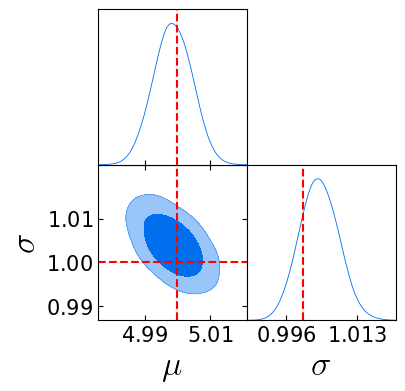

In [4]:
results_chain = sampler.get_samples()

res = np.array([results_chain['mu'], results_chain['sigma']])#, results_chain['lower']])

param_names = [r'$\mu$', r'$\sigma$']#, r'$x_\mathrm{min}$']
getdist_plot(res, param_names, true_params, pred_params)

## Full normal + $f_n$ correction

In [ ]:
@jax.jit
def log_f_n_1D_gauss(x_cut: float, mu: float, sigma: float):
    """Calculate the normalisation of the 1D Gaussian likelihood, given the limit on x and the mean and std of the Gaussian"""

    f_n = 0.5 * (1 - jax_erf((x_cut - mu) / (sigma * jnp.sqrt(2))))

    return jnp.log(f_n)


def model_1D_gauss(x, x_cut):

    mu = numpyro.sample('mu', dist.Uniform(-20., 20.))
    sigma = numpyro.sample('sigma', dist.HalfNormal(10))

    ll_1D_gauss_full = numpyro.sample('ll_full', dist.Normal(mu, sigma), obs=x)

    log_fn = log_f_n_1D_gauss(x_cut, mu, sigma)

    loglike = ll_1D_gauss_full - log_fn

    numpyro.factor('loglike', loglike)

In [6]:
sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(model_1D_gauss),
    num_chains=1,
    num_warmup=1000,
    num_samples=3000
)

sampler.run(jax.random.PRNGKey(0), x_data, x_min)

sample: 100%|██████████| 4000/4000 [04:36<00:00, 14.48it/s, 1023 steps of size 9.80e-07. acc. prob=0.87]


Removed no burn in


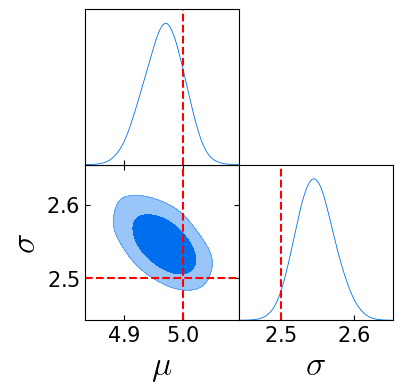

In [ ]:
results_chain = sampler.get_samples()

res = np.array([results_chain['mu'], results_chain['sigma']])#, results_chain['lower']])

param_names = [r'$\mu$', r'$\sigma$']#, r'$x_\mathrm{min}$']
getdist_plot(res, param_names, true_params, pred_params)

# Truncated 1D Gaussian with errors

Add the errors first and then truncate (mimicking real scenario).

True parameters:  [5.0, 2.5, 1.0]
Predicted parameters:  [Array(5.1396623, dtype=float32), Array(0.88122535, dtype=float32), Array(3.5001721, dtype=float32)]


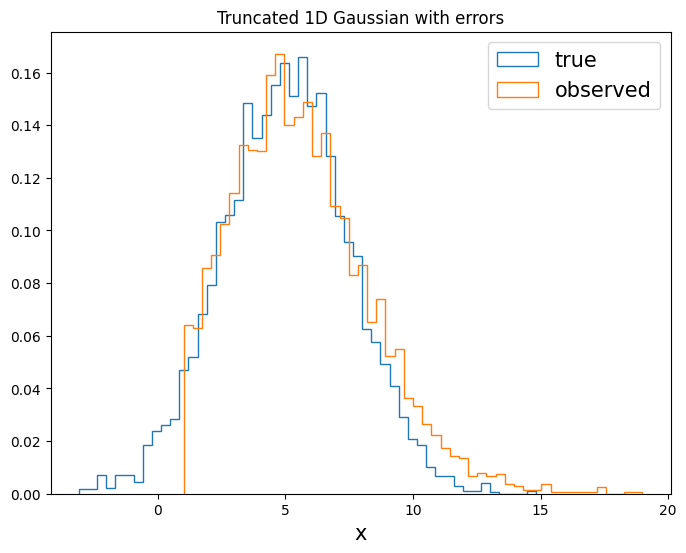

In [17]:
np.random.seed(42)

# Generate data
sigma_cut = 1.5
N_data = 5000
mean_x = 5.0
x_min = 1.0
e_x = dist.InverseGamma(concentration=20, rate=25/0.6).sample(jax.random.PRNGKey(0), sample_shape=(N_data, ))
true_params = [mean_x, sigma_x, x_min]

# Convolve true distribution with error distribution
x_true = np.random.normal(loc=mean_x, scale=sigma_x, size=N_data)
err_x = dist.HalfNormal(2.0).sample(jax.random.PRNGKey(0), sample_shape=(N_data, ))
x_true_with_err = x_true + np.random.normal(size=N_data) * err_x

# Truncate the data
x_obs = x_true_with_err[x_true_with_err >= x_min]

print("True parameters: ", true_params)
print("Predicted parameters: ", pred_params)

plt.figure(figsize=(8, 6))
plt.title(r'Truncated 1D Gaussian with errors')
plt.hist(x_true, bins=50, label='true', density=True, histtype='step')
plt.hist(x_obs, bins=50, label='observed', density=True, histtype='step')
plt.xlabel('x', fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [ ]:
def model_1D_gauss(x, err_x, x_cut):

    mu = numpyro.sample('mu', dist.Uniform(-20., 20.))
    sigma = numpyro.sample('sigma', dist.HalfNormal(10))

    ll_1D_gauss_full = numpyro.sample('ll_full', dist.Normal(mu, sigma), obs=x)

    log_fn = log_f_n_1D_gauss(x_cut, mu, sigma)

    loglike = ll_1D_gauss_full - log_fn

    numpyro.factor('loglike', loglike) 